In [174]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from Python_files import time_integration_functions as TST
# from python_files import TLM_tests as TT
from Python_files import ETLM as ETLMC
from Python_files import LETLM as LETLMC
from Python_files import IETLM as IETLMC
from Python_files import GETLM as GETLMC

torch.set_default_dtype(torch.float64)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
# We will start by testing Crank-Nicolson
# Once the LETLM and IETLM have been updated add them into here

# The first step is to spin up the model, to do that we need to set the model parameters
#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.5 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.CN_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)
print(x_in)


100%|██████████| 999/999 [00:00<00:00, 19753.30it/s]

[tensor([[8.0000]]), tensor([[8.0000]])]


In [27]:
# We now need to generate the ensembles
# However, before we do this we need to know how many ensemble we need
# To calculate this we need to first specify what stencil members we need to sample
stencil_members_future_CN = [-2,-1,0,1]
stencil_members_current_CN = [-2,-1,0,1]
stencil_members_past_CN = []
stencil_members_large_CN = [stencil_members_future_CN, stencil_members_current_CN, stencil_members_past_CN]
ensemble_size_CN = len(stencil_members_future_CN) + len(stencil_members_current_CN) + len(stencil_members_past_CN) + 5

# Now that we know this we can generate our ensemble 
# We will now test out the ensemble generator 
stand_dev = 10**(-7)
# print(x_out)

Chi, Xi, X = GETLMC.GETLM_ensemble_generator(x_out[0],x_out[1], ensemble_size_CN, stand_dev, model,model_parameters)

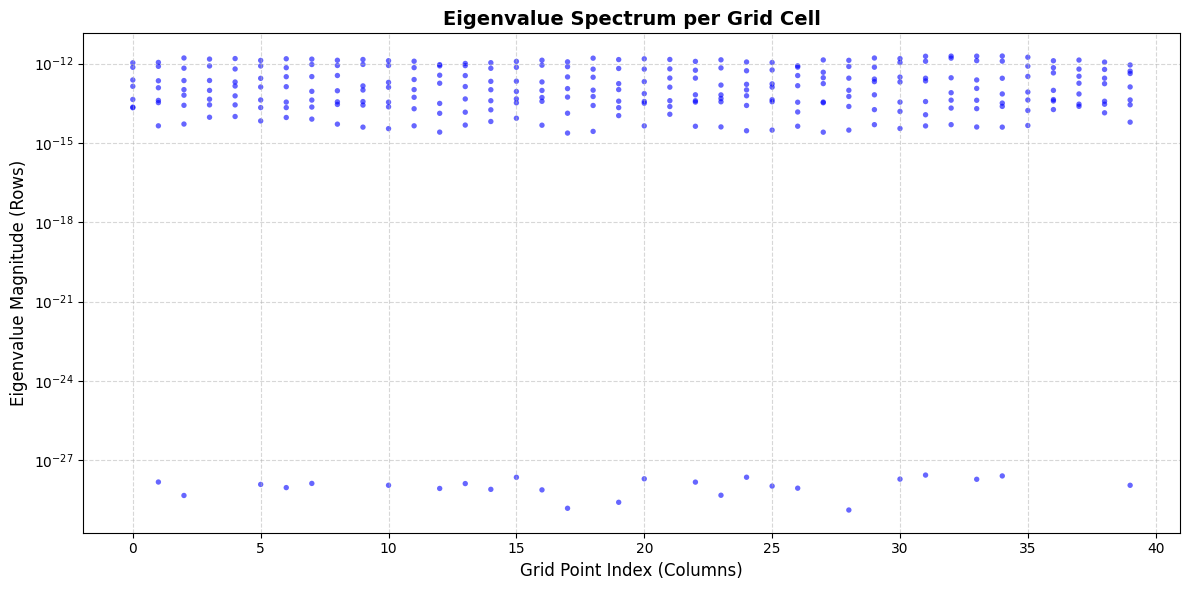

In [28]:
# We can now generate our GETLM 
k = 1 # number of zero eigenvalue eigenvalues

N_tilde, L_tilde, K_tilde = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k)

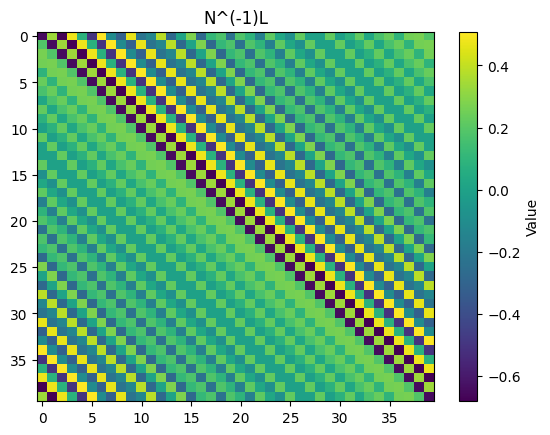

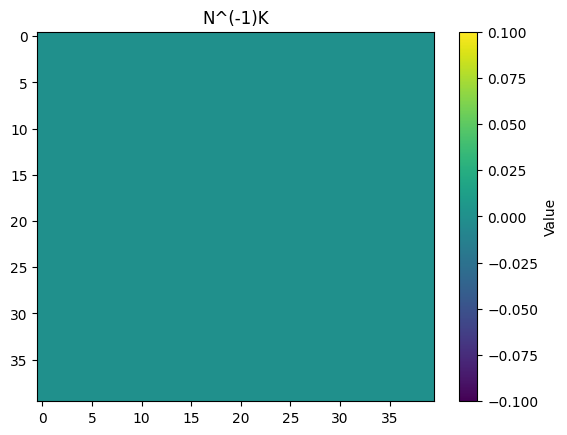

In [29]:
plt.imshow(torch.pinverse(N_tilde) @ L_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)L")
plt.show()
plt.imshow(torch.pinverse(N_tilde) @ K_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)K")
plt.show()

In [36]:
# We will now do Runge-Kutta 4

# The first step is to spin up the model, to do that we need to set the model parameters
#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.rk4_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)
print(x_in)



100%|██████████| 999/999 [00:00<00:00, 16472.89it/s]

[tensor([8.0000]), tensor([8.0000])]


In [37]:
# We now need to generate the ensembles
# However, before we do this we need to know how many ensemble we need
# To calculate this we need to first specify what stencil members we need to sample
stencil_members_future_RK4 = [0]
stencil_members_current_RK4 = [-8,-7,-6,5,-4,-3,-2,-1,0,1,2,3,4,5]
stencil_members_past_RK4 = []
stencil_members_large_RK4 = [stencil_members_future_RK4, stencil_members_current_RK4, stencil_members_past_RK4]
ensemble_size_RK4 = len(stencil_members_future_RK4) + len(stencil_members_current_RK4) + len(stencil_members_past_RK4) + 5

# Now that we know this we can generate our ensemble 
# We will now test out the ensemble generator 
stand_dev = 10**(-7)


Chi, Xi, X = GETLMC.GETLM_ensemble_generator(x_out[0],x_out[1], ensemble_size_RK4, stand_dev, model,model_parameters)

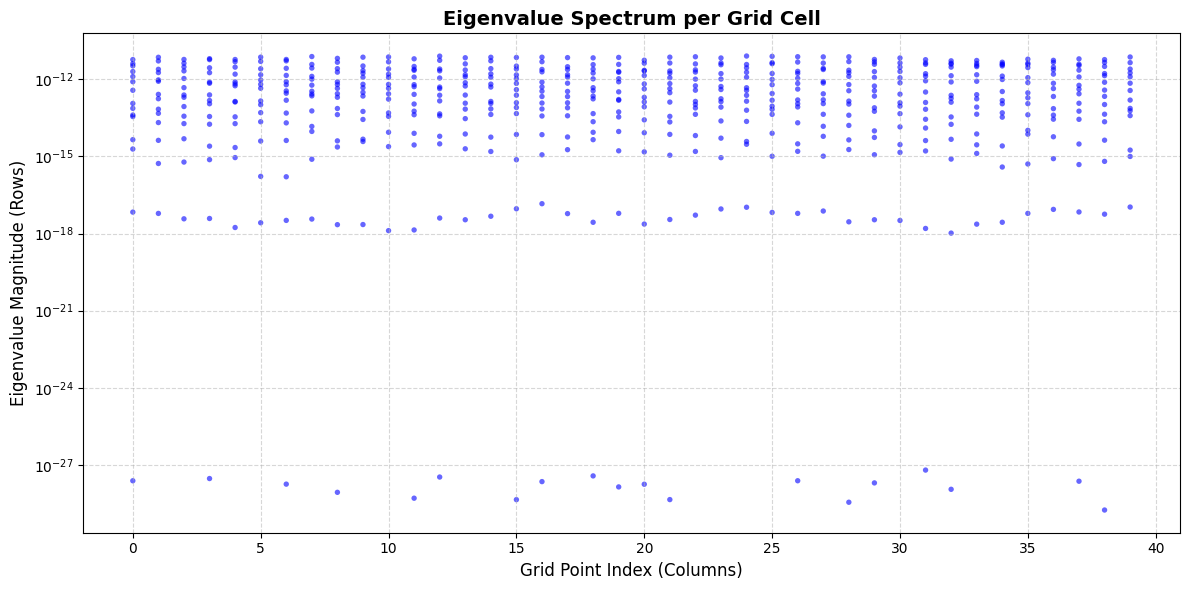

In [40]:
# We can now generate our GETLM 
k = 2 # number of zero eigenvalue eigenvalues

N_tilde, L_tilde, K_tilde = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_RK4, model_parameters, ensemble_size_RK4, k)

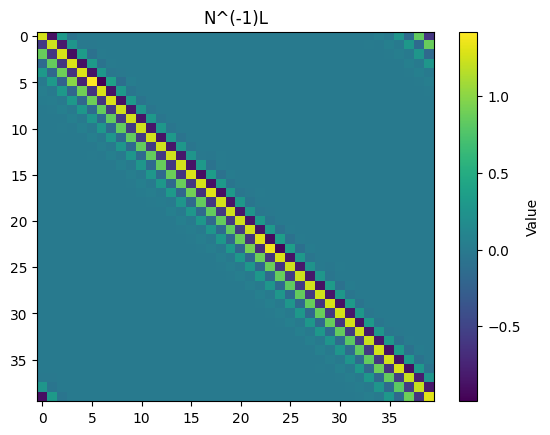

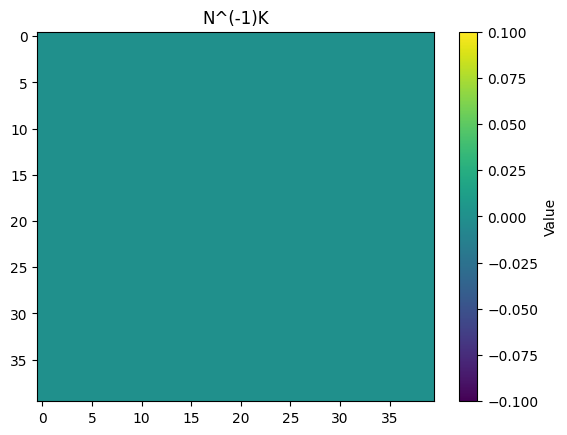

In [41]:
plt.imshow(torch.pinverse(N_tilde) @ L_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)L")
plt.show()
plt.imshow(torch.pinverse(N_tilde) @ K_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)K")
plt.show()

In [51]:
# We will now do Leapfrog

# The first step is to spin up the model, to do that we need to set the model parameters
#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.08 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.LF_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)
print(x_in)


100%|██████████| 999/999 [00:00<00:00, 39492.08it/s]

[tensor([8.0000]), tensor([8.0000])]


In [52]:
# We now need to generate the ensembles
# However, before we do this we need to know how many ensemble we need
# To calculate this we need to first specify what stencil members we need to sample
stencil_members_future_LF = [0]
stencil_members_current_LF = [-2,-1,0,1]
stencil_members_past_LF = [0]
stencil_members_large_LF = [stencil_members_future_LF, stencil_members_current_LF, stencil_members_past_LF]
ensemble_size_LF = len(stencil_members_future_LF) + len(stencil_members_current_LF) + len(stencil_members_past_LF) + 5

# Now that we know this we can generate our ensemble 
# We will now test out the ensemble generator 
stand_dev = 10**(-7)


Chi, Xi, X = GETLMC.GETLM_ensemble_generator(x_out[0],x_out[1], ensemble_size_LF, stand_dev, model,model_parameters)

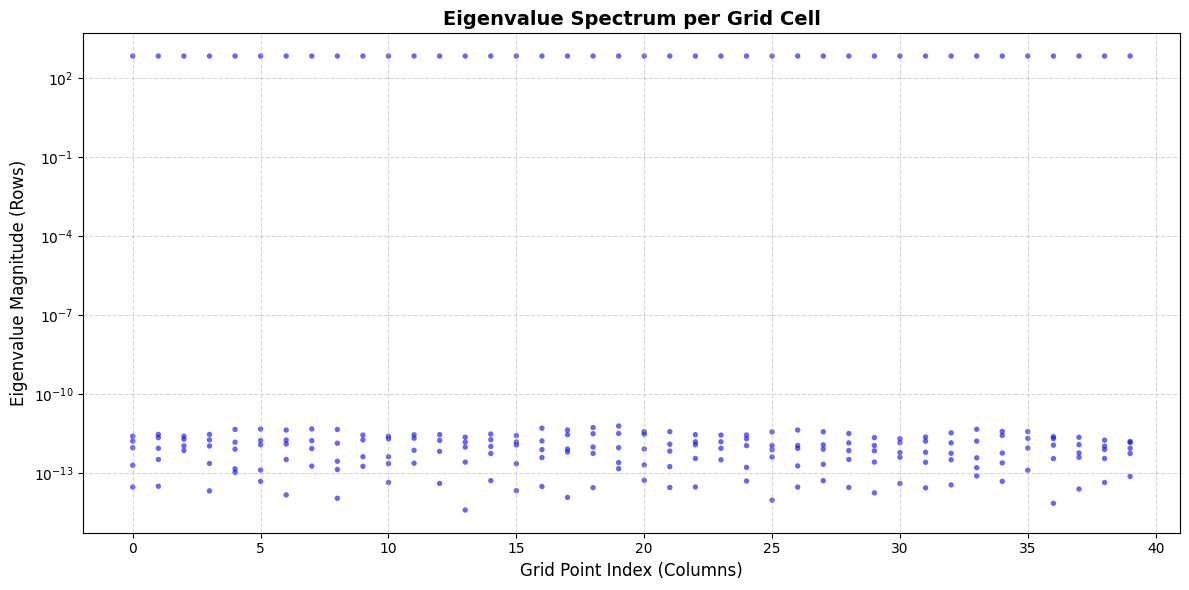

In [57]:
# We can now generate our GETLM 
k = 3 # number of zero eigenvalue eigenvalues

N_tilde, L_tilde, K_tilde = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_LF, model_parameters, ensemble_size_LF, k)

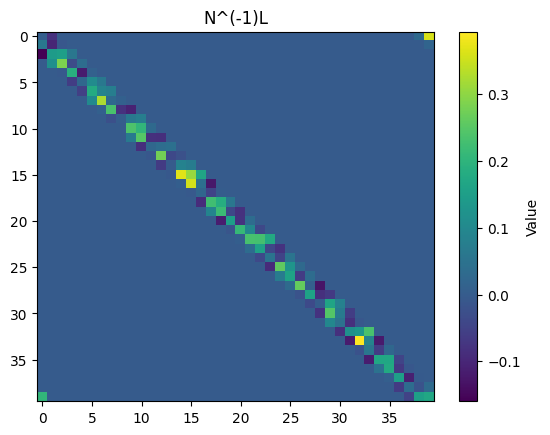

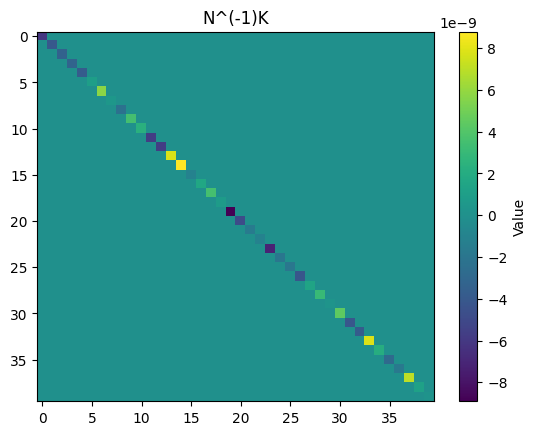

In [58]:
plt.imshow(torch.pinverse(N_tilde) @ L_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)L")
plt.show()
plt.imshow(torch.pinverse(N_tilde) @ K_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)K")
plt.show()

In [86]:
# We will now do the multistage method

model = TST.rk4_L96
# print(x_out)
stencil_members_future_RK4 = [0]
stencil_members_current_RK4 = [-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5]
stencil_members_past_RK4 = []
stencil_members_large_RK4 = [stencil_members_future_RK4, stencil_members_current_RK4, stencil_members_past_RK4]
ensemble_size_RK4 = len(stencil_members_future_RK4) + len(stencil_members_current_RK4) + len(stencil_members_past_RK4) + 5

Ensembles, test_results = GETLMC.GETLM_ensemble_generator_mult(x_out[0],x_out[1], ensemble_size_RK4, 10**(-7),model,model_parameters,number_of_steps=10)
print(len(Ensembles))

20


In [ ]:
# Now that we have our ensembles we need to find the GETLM for each time step
TLMS = []

for i in range(len(Ensembles)-1):
    Chi = Ensembles[i+1][0]
    Xi = Ensembles[i+1][1]
    X = Ensembles[i+1][2]
    k = 1 # number of zero eigenvalue eigenvalues
    N_tilde, L_tilde, K_tilde = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_RK4, model_parameters, ensemble_size_RK4, k, plot = True)
    TLMS.append([N_tilde, L_tilde, K_tilde])
    plt.imshow(torch.pinverse(N_tilde) @ L_tilde,aspect='auto', cmap='viridis')
    plt.colorbar(label='Value')
    plt.title("2D Tensor Heatmap")
    plt.title("N^(-1)L")
    plt.show() 
    # plt.imshow(torch.pinverse(N_tilde) @ K_tilde,aspect='auto', cmap='viridis')
    # plt.colorbar(label='Value')
    # plt.title("2D Tensor Heatmap")
    # plt.title("N^(-1)K")
    # plt.show()


IndexError: too many indices for tensor of dimension 1

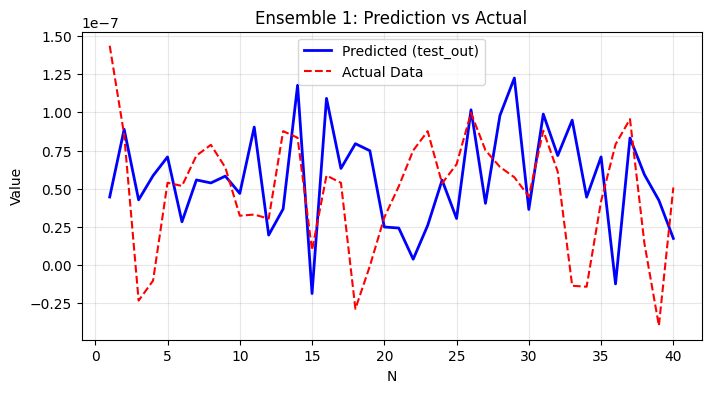

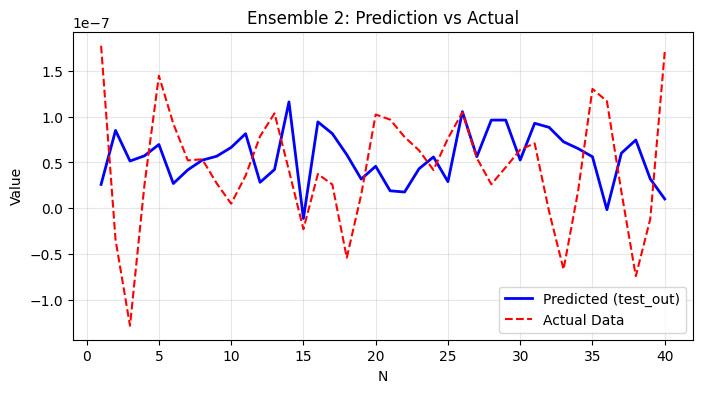

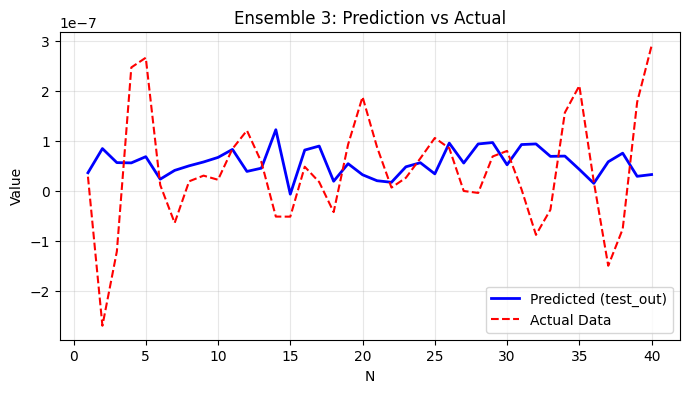

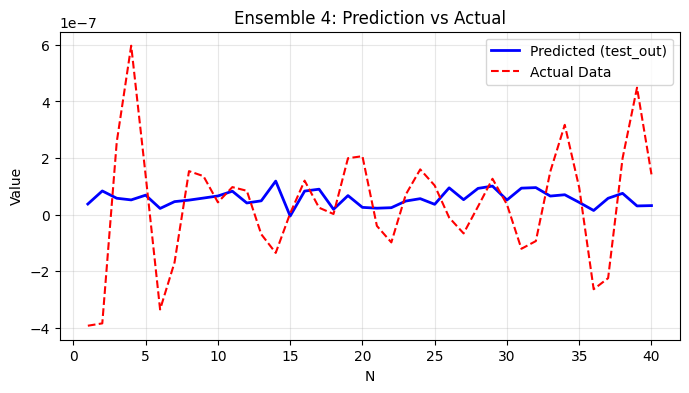

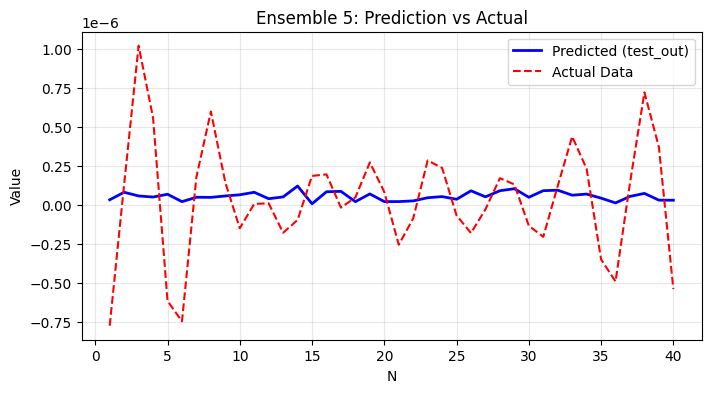

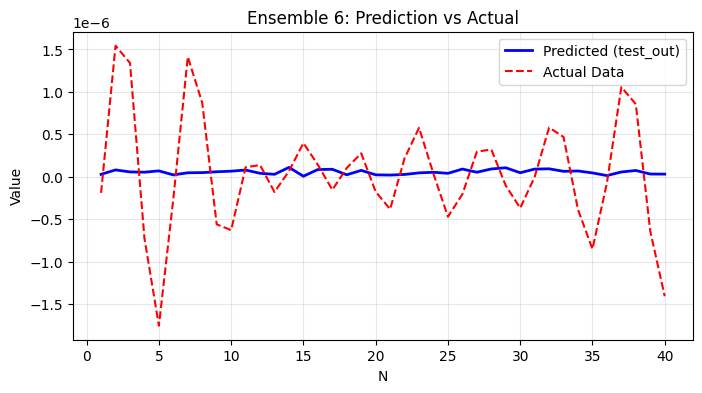

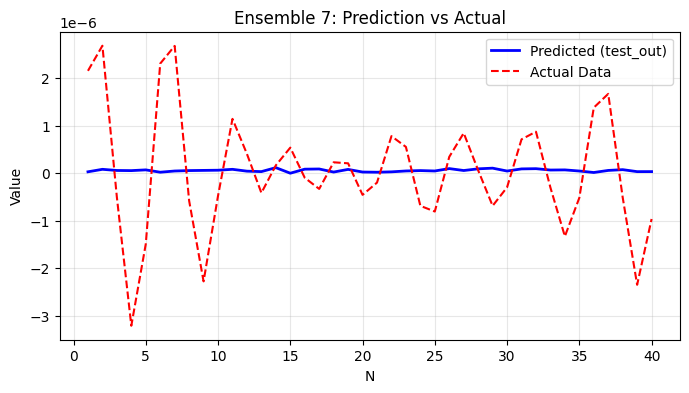

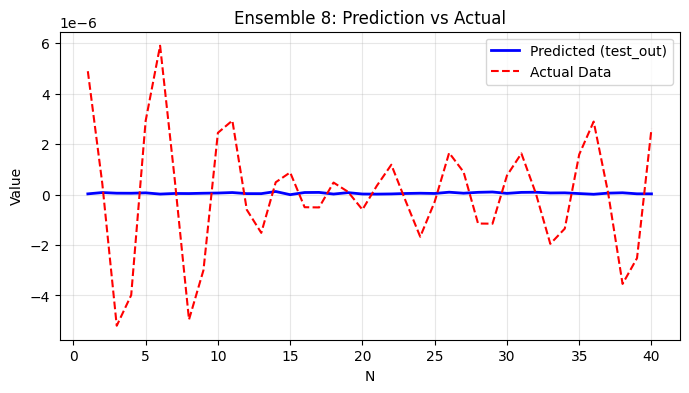

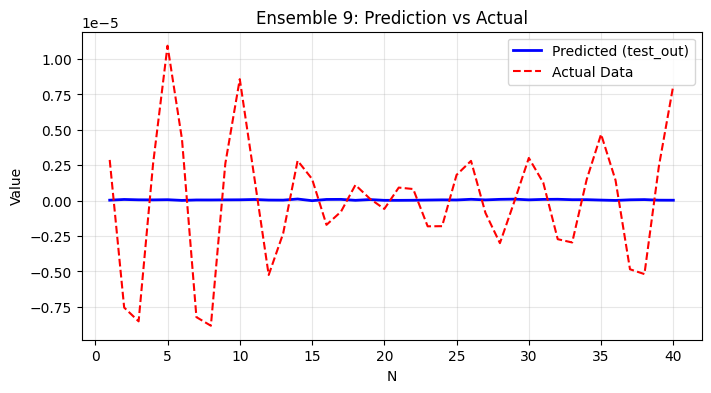

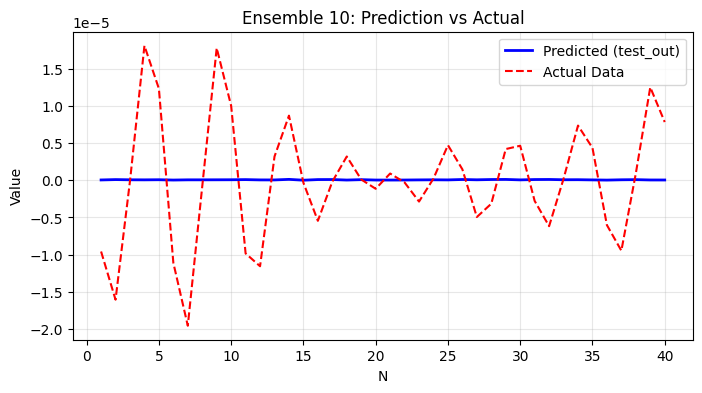

IndexError: list index out of range

In [ ]:


# 1. Initialize 
x_values = np.arange(1, N + 1)
test_pert = test_results[0]
# Initial state (length 80)
current_test_state = torch.cat((test_pert[0], test_pert[1])).flatten()

# print(test_pert)
for i in range(len(Ensemble_final) - 1):
    # Setup matrices (Double check your TLMS indices here!)
    N_tilde = TLMS[i][0]
    L_tilde = TLMS[i][1] 
    K_tilde = TLMS[i][2]

    # Calculate GETLM (Result: 40 x 80)
    GETLM = torch.cat(((torch.pinverse(N_tilde) @ L_tilde).squeeze(), 
                       (torch.pinverse(N_tilde) @ K_tilde).squeeze()), dim=1)
    
    # 2. Project state: [40, 80] @ [80] -> [40]
    # We use a temporary variable so we don't overwrite the '80' length needed for the next loop
    test_out = GETLM @ current_test_state
    test_actual = test_results[i+1][0].flatten()

    # 3. Plotting
    plt.figure(figsize=(8, 4))
    
    # Convert tensors to numpy for plotting
    # Use .detach().cpu() to ensure it works regardless of device/autograd
    plt.plot(x_values, test_out.detach().cpu().numpy(), label='Predicted (test_out)', color='blue', linewidth=2)
    plt.plot(x_values, test_actual.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
    
    plt.title(f"Ensemble {i+1}: Prediction vs Actual")
    plt.xlabel("N")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show() # This creates a fresh window/plot for each step in the loop

In [ ]:
def GETLM_ensemble_generator_mult(x_current, x_past, ensemble_size, standard_deviation, model, model_parameters, test_pert, number_of_steps = 1):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters
    # We first define our test perturbation
    test_guess = []
    state_test_pert = [x_current + test_pert, x_past]
    test_guess.append(x_past)
    test_guess.append(state_test_pert[0])
    for i in range(number_of_steps):
        state_test_pert = TST.run_model(state_test_pert, model, model_parameters)
        test_guess.append(state_test_pert[0])
        # print(len(test_guess)) # This should be number of steps + 2
    
    # Now that we have defined our test perturbation we can run our perturbed ensemble members
    Ensembles = []
    # We first make copies of our original state vectors
    x_past_ensemble = x_past.repeat(1, ensemble_size)
    ensemble_unpert = x_current.repeat(1, ensemble_size)

    # we now need to add random normal noise to the unperturbed ensembles
    ensemble_pert = ensemble_unpert + torch.randn(N, ensemble_size) * standard_deviation

    Ensembles.append(x_past_ensemble)
    Ensembles.append(ensemble_pert)

    for i in range(number_of_steps):
        Chi = torch.zeros((N,ensemble_size))
        X = Ensembles[-2]
        Xi = Ensembles[-1]
        for j in range(ensemble_size):
            # Xj = X[:,j]
            # Xij = Xi[:,j]
            Xj = X[:, j:j+1]   # Preserves 2D shape (N, 1)
            Xij = Xi[:, j:j+1]
            Chi_j = TST.run_model([Xij,Xj], model, model_parameters)
            Chi[:,j] = Chi_j[0]
        Ensembles.append(Chi)

    # Now we have the ensembles of perturbed runs, but we now need to remove the non-linear term
# To do this we start by doing a controlled run
    unpert_run = []
    unpert_run.append(x_past)
    print(x_past.shape)
    unpert_run.append(x_current)
    for i in range(number_of_steps):
        # print(unpert_run[-2].shape)
        in_run = [unpert_run[-2], unpert_run[-1]]
        out_run = TST.run_model(in_run, model, model_parameters)
        unpert_run.append(out_run[0])

    
    

    # now that we have our unperturbed run we can subtract it from our test run and our perturbed run
    # We will start with the test run
    test_final = []
    for i in range(len(test_guess)):
        test_final.append(test_guess[i] - unpert_run[i])

    # We will now repeat this for the perturbed runs
    Ensemble_final = []
    for i in range(len(Ensembles)):
        unpert_matrix = (unpert_run[i]).repeat(1, ensemble_size)
        # print(unpert_matrix.shape)
        # print((Ensembles[i] - unpert_matrix).shape)
        Ensemble_final.append(Ensembles[i] - unpert_matrix)



    return test_final, Ensemble_final, Ensembles






In [177]:
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.rk4_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
for i in tqdm(range(spin_up_time-1)):
    # print(len(x_in[0]))
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)

print(x_out[0].shape)
print(type(x_out))

print(type(x_out[0]))
print(x_out[0].shape)

print(type(x_out[1]))
print(x_out[1].shape)


100%|██████████| 999/999 [00:00<00:00, 17085.40it/s]

torch.Size([1])
<class 'list'>
<class 'torch.Tensor'>
torch.Size([1])
<class 'torch.Tensor'>
torch.Size([1])


In [178]:
test_pert = torch.randn((N,1))
model = TST.rk4_L96
# print(x_out)
stencil_members_future_RK4 = [0]
stencil_members_current_RK4 = [-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5]
stencil_members_past_RK4 = []
stencil_members_large_RK4 = [stencil_members_future_RK4, stencil_members_current_RK4, stencil_members_past_RK4]
ensemble_size_RK4 = len(stencil_members_future_RK4) + len(stencil_members_current_RK4) + len(stencil_members_past_RK4) + 5

test_final, Ensemble_final, Ensembles = GETLM_ensemble_generator_mult(x_out[0],x_out[1], ensemble_size_RK4, 10**(-7),model,model_parameters,test_pert, number_of_steps=10)
# print(len(Ensembles))

In [179]:
print(Ensemble_final[0].shape)
print(ensemble_size_RK4)

torch.Size([1, 20])
20
